In [1]:
# Phase 11-R – Strong Stage II | Cell 1: Setup + library check

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pickle
import sys
import importlib

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR   = PROJECT / "outputs" / "phase11"
OUT_DATA  = OUT_DIR / "data"
OUT_TAB   = OUT_DIR / "tables"
OUT_FIG   = OUT_DIR / "figures"
OUT_MODEL = OUT_DIR / "models"
OUT_LOG   = OUT_DIR / "logs"
for d in [OUT_DATA, OUT_TAB, OUT_FIG, OUT_MODEL, OUT_LOG]:
    d.mkdir(parents=True, exist_ok=True)

P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"

print("=" * 60)
print("Phase 11-R – Strong Stage II Reactive Policy | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")
print("Mode      : FULL multi-agent | equal protocol | GraphSAGE only")

# Data
base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from economics_env import EconomicsNetworkEnv
from shock_env import ShockEconomicsEnv, SHOCK_SERIES, SEVERITY

print(f"base_features : {base_features.shape}")
print(f"emb_GraphSAGE : {emb.shape}")
print(f"shock series  : {list(SHOCK_SERIES.keys())}")

# Library inventory
libs = {}
for name in ["torch", "gymnasium", "stable_baselines3", "pettingzoo", "supersuit", "ray", "tianshou"]:
    try:
        m = importlib.import_module(name)
        ver = getattr(m, "__version__", "ok")
        libs[name] = ver
        print(f"  [OK] {name:18s} {ver}")
    except Exception as e:
        libs[name] = None
        print(f"  [--] {name:18s} NOT FOUND")

# Decide stack
has_pz = libs.get("pettingzoo") is not None
has_ray = libs.get("ray") is not None
has_ts  = libs.get("tianshou") is not None
has_sb3 = libs.get("stable_baselines3") is not None

if has_ray:
    stack = "rllib"
elif has_pz and has_sb3:
    stack = "pettingzoo+sb3"
elif has_ts:
    stack = "tianshou"
else:
    stack = "sb3_joint+custom_ma"

print(f"\nSelected stack: {stack}")
print("Target algos (equal): MAPPO, MADDPG, QMIX, IPPO, PPO, A2C, A3C, REINFORCE")

pd.DataFrame([{"lib": k, "version": v} for k, v in libs.items()]).to_csv(
    OUT_TAB / "phase11r_library_inventory.csv", index=False
)
with open(OUT_DATA / "phase11r_stack.txt", "w", encoding="utf-8") as f:
    f.write(stack)

print("\nCell 1 completed successfully.")

Phase 11-R – Strong Stage II Reactive Policy | Cell 1
Timestamp : 2026-10-01 21:57:54
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase11
Mode      : FULL multi-agent | equal protocol | GraphSAGE only
base_features : (378, 16)
emb_GraphSAGE : (378, 32)
shock series  : ['standard', 'strong']
  [OK] torch              2.13.0+cpu
  [OK] gymnasium          1.3.0
  [OK] stable_baselines3  2.9.0
  [OK] pettingzoo         1.27.0
  [OK] supersuit          3.11.0


2026-10-01 21:58:01,731	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


  [OK] ray                2.58.0
  [OK] tianshou           2.0.1

Selected stack: rllib
Target algos (equal): MAPPO, MADDPG, QMIX, IPPO, PPO, A2C, A3C, REINFORCE

Cell 1 completed successfully.


In [2]:
# Phase 11-R – Cell 2: PettingZoo multi-agent shock environment

from pathlib import Path
import sys
import textwrap
import numpy as np
import pandas as pd

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase11" / "tables"

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print("=" * 60)
print("Phase 11-R – Cell 2: PettingZoo MultiAgent Shock Env")
print("=" * 60)

src = textwrap.dedent(r'''
import functools
import numpy as np
from gymnasium import spaces
from pettingzoo import ParallelEnv
from shock_env import ShockEconomicsEnv

AGENTS = ["Government", "CentralBank", "BankingSector"]
AGENT_ACT_DIM = 2
JOINT_DIM = len(AGENTS) * AGENT_ACT_DIM

class EconomicsMAParallelEnv(ParallelEnv):
    """
    PettingZoo ParallelEnv over ShockEconomicsEnv.
    Shared observation; per-agent Box(2,) actions.
    Joint mapping -> base (tax, subsidy, investment, credit).
    Cooperative shared reward.
    """
    metadata = {"name": "economics_ma_shock_v1", "render_modes": []}

    def __init__(self, base_features, embeddings, sr_vector, panel_index, nodes,
                 level="moderate", shock_type="BankingCrisis", severity="Moderate",
                 shock_series="standard", seed=None):
        super().__init__()
        self.base_features = base_features
        self.embeddings = embeddings
        self.sr_vector = sr_vector
        self.panel_index = panel_index
        self.nodes = nodes
        self.level = level
        self.shock_type = shock_type
        self.severity = severity
        self.shock_series = shock_series
        self._seed = seed

        self.possible_agents = list(AGENTS)
        self.agents = list(AGENTS)
        self._base = None
        self._obs = None

        # spaces filled after first reset dims known; use fixed from base env
        tmp = ShockEconomicsEnv(
            base_features, embeddings, sr_vector, panel_index, nodes,
            level=level, shock_type=None, severity=None, shock_series=shock_series, seed=0,
        )
        obs0, _ = tmp.reset(seed=0)
        self._obs_dim = int(obs0.shape[0])
        self._obs_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self._obs_dim,), dtype=np.float32)
        self._act_space = spaces.Box(low=-1.0, high=1.0, shape=(AGENT_ACT_DIM,), dtype=np.float32)

    @functools.lru_cache(maxsize=None)
    def observation_space(self, agent):
        return self._obs_space

    @functools.lru_cache(maxsize=None)
    def action_space(self, agent):
        return self._act_space

    def _make_base(self, seed=None):
        return ShockEconomicsEnv(
            self.base_features, self.embeddings, self.sr_vector, self.panel_index, self.nodes,
            level=self.level, shock_type=self.shock_type, severity=self.severity,
            shock_series=self.shock_series, seed=seed,
        )

    def _map_actions(self, action_dict):
        joint = []
        for a in self.possible_agents:
            act = np.asarray(action_dict.get(a, np.zeros(AGENT_ACT_DIM, dtype=np.float32)), dtype=np.float32)
            act = np.clip(act, -1.0, 1.0)
            if act.shape[0] != AGENT_ACT_DIM:
                act = np.resize(act, AGENT_ACT_DIM)
            joint.append(act)
        joint = np.concatenate(joint, axis=0)
        # Government: tax, subsidy | CentralBank: rate, QE | Banking: credit, risk
        tax, sub = joint[0], joint[1]
        rate, qe = joint[2], joint[3]
        credit, risk = joint[4], joint[5]
        base_action = np.array([
            tax,
            0.5 * sub + 0.3 * qe,
            0.4 * qe + 0.3 * risk,
            0.5 * credit + 0.2 * rate,
        ], dtype=np.float32)
        return base_action, joint

    def reset(self, seed=None, options=None):
        if seed is None:
            seed = self._seed
        self._base = self._make_base(seed)
        obs, info = self._base.reset(seed=seed)
        self.agents = list(self.possible_agents)
        self._obs = obs.astype(np.float32)
        obs_dict = {a: self._obs.copy() for a in self.agents}
        infos = {a: {"shock": self._base.last_shock_info} for a in self.agents}
        return obs_dict, infos

    def step(self, action_dict):
        base_action, joint = self._map_actions(action_dict)
        obs, reward, term, trunc, info = self._base.step(base_action)
        self._obs = obs.astype(np.float32)
        # cooperative: same reward to all
        rews = {a: float(reward) for a in self.agents}
        terms = {a: bool(term) for a in self.agents}
        truncs = {a: bool(trunc) for a in self.agents}
        obs_dict = {a: self._obs.copy() for a in self.agents}
        infos = {a: {**info, "joint_action": joint, "shock": self._base.last_shock_info} for a in self.agents}
        # PZ requires emptying agents when done
        if term or trunc:
            self.agents = []
        return obs_dict, rews, terms, truncs, infos
''')

mod_path = OUT_DATA / "economics_ma_pettingzoo.py"
mod_path.write_text(src, encoding="utf-8")
print(f"Saved → {mod_path}")

if str(OUT_DATA) not in sys.path:
    sys.path.insert(0, str(OUT_DATA))
import importlib
import economics_ma_pettingzoo
importlib.reload(economics_ma_pettingzoo)
from economics_ma_pettingzoo import EconomicsMAParallelEnv, AGENTS

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

for series in ["standard", "strong"]:
    env = EconomicsMAParallelEnv(
        base_features, emb, sr, panel, nodes,
        level="moderate", shock_type="BankingCrisis", severity="Moderate",
        shock_series=series, seed=0,
    )
    obs, infos = env.reset(seed=0)
    total = 0.0
    for _ in range(5):
        acts = {a: env.action_space(a).sample() for a in env.agents}
        obs, rews, terms, truncs, infos = env.step(acts)
        total += list(rews.values())[0]
        if not env.agents:
            break
    print(f"{series:8s} | agents={AGENTS} | obs_dim={env._obs_dim} | "
          f"act_dim={env.action_space(AGENTS[0]).shape} | R5={total:.3f} | "
          f"shock={list(infos.values())[0].get('shock') if infos else None}")

print("\nCell 2 completed successfully.")

Phase 11-R – Cell 2: PettingZoo MultiAgent Shock Env
Saved → D:\univercity\omid_project\economics_project\outputs\phase11\data\economics_ma_pettingzoo.py
standard | agents=['Government', 'CentralBank', 'BankingSector'] | obs_dim=69 | act_dim=(2,) | R5=-1.446 | shock={'shock_type': 'BankingCrisis', 'severity': 'Moderate', 'series': 'standard', 'delta_sr': -0.14960978269305084}
strong   | agents=['Government', 'CentralBank', 'BankingSector'] | obs_dim=69 | act_dim=(2,) | R5=-1.938 | shock={'shock_type': 'BankingCrisis', 'severity': 'Moderate', 'series': 'strong', 'delta_sr': -0.24960978269305084}

Cell 2 completed successfully.


In [5]:
# Phase 11-R – Cell 3 (fixed): MAPPO + IPPO without ray.tune

from pathlib import Path
import sys
import os
import numpy as np
import pandas as pd

os.environ.setdefault("RAY_DEDUP_LOGS", "0")

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB = PROJECT / "outputs" / "phase11" / "tables"

for p in [str(P8), str(P10), str(OUT_DATA)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from economics_ma_pettingzoo import EconomicsMAParallelEnv, AGENTS

print("=" * 60)
print("Phase 11-R – Cell 3 (fixed): MAPPO + IPPO")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

TOTAL_TIMESTEPS = 50000
EVAL_EPISODES = 20
TRAIN_SHOCK = ("BankingCrisis", "Moderate")
SERIES_LIST = ["standard", "strong"]
SEED = 0

def make_raw_env(series, seed=SEED):
    return EconomicsMAParallelEnv(
        base_features, emb, sr, panel, nodes,
        level="moderate",
        shock_type=TRAIN_SHOCK[0], severity=TRAIN_SHOCK[1],
        shock_series=series, seed=seed,
    )

# ---------- Try RLlib without ray.tune ----------
USE_RLLIB = False
try:
    import ray
    from ray.rllib.env.wrappers.pettingzoo_env import ParallelPettingZooEnv
    from ray.rllib.algorithms.ppo import PPOConfig
    if not ray.is_initialized():
        ray.init(ignore_reinit_error=True, include_dashboard=False, logging_level="ERROR")
    USE_RLLIB = True
    print("Backend: RLlib (no ray.tune)")
except Exception as e:
    print(f"RLlib unavailable ({type(e).__name__}: {e})")
    print("Backend: PettingZoo + SB3 joint/independent fallback")

results = []

def evaluate_raw(policy_fn, series, n_ep=EVAL_EPISODES, seed=10_000):
    rewards, recoveries, sr_imps = [], [], []
    for ep in range(n_ep):
        env = make_raw_env(series, seed=seed + ep)
        obs_dict, infos = env.reset(seed=seed + ep)
        sr0 = float(np.mean(env._base.current_sr))
        ep_r, info_last = 0.0, {}
        while env.agents:
            actions = policy_fn(obs_dict, env)
            obs_dict, rews, terms, truncs, infos = env.step(actions)
            ep_r += float(np.mean(list(rews.values())))
            info_last = list(infos.values())[0] if infos else {}
            if any(terms.values()) or any(truncs.values()):
                break
        rewards.append(ep_r)
        recoveries.append(float(np.mean(env._base.current_sr)) - sr0)
        sr_imps.append(info_last.get("sr_improve", np.nan))
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "median_reward": float(np.median(rewards)),
        "mean_recovery": float(np.mean(recoveries)),
        "std_recovery": float(np.std(recoveries)),
        "mean_sr_improve": float(np.nanmean(sr_imps)),
    }

if USE_RLLIB:
    def build_and_train(series, independent=False):
        def env_creator(config):
            return ParallelPettingZooEnv(make_raw_env(series, seed=SEED))

        probe = ParallelPettingZooEnv(make_raw_env(series, 0))
        obs_space, act_space = probe.observation_space, probe.action_space
        if hasattr(obs_space, "spaces"):
            sample_obs = list(obs_space.spaces.values())[0]
            sample_act = list(act_space.spaces.values())[0]
            agent_ids = list(obs_space.spaces.keys())
        else:
            sample_obs, sample_act, agent_ids = obs_space, act_space, list(AGENTS)
        probe.close()

        if independent:
            policies = {a: (None, sample_obs, sample_act, {}) for a in agent_ids}
            mapping = lambda agent_id, *args, **kwargs: agent_id
            train_pols = list(agent_ids)
        else:
            policies = {"shared_policy": (None, sample_obs, sample_act, {})}
            mapping = lambda agent_id, *args, **kwargs: "shared_policy"
            train_pols = ["shared_policy"]

        cfg = (
            PPOConfig()
            .environment(env=env_creator, disable_env_checking=True)
            .framework("torch")
            .env_runners(num_env_runners=0, num_envs_per_env_runner=1, rollout_fragment_length=40)
            .training(lr=3e-4, gamma=0.99, train_batch_size=2048, minibatch_size=256, num_epochs=10,
                      model={"fcnet_hiddens": [128, 128]})
            .multi_agent(policies=policies, policy_mapping_fn=mapping, policies_to_train=train_pols)
            .debugging(log_level="ERROR")
            .api_stack(enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False)
        )
        algo = cfg.build()
        steps, it = 0, 0
        while steps < TOTAL_TIMESTEPS:
            result = algo.train()
            ts = (
                result.get("num_env_steps_sampled_lifetime")
                or result.get("env_runners", {}).get("num_env_steps_sampled_lifetime")
                or result.get("timesteps_total")
                or 0
            )
            steps = int(ts) if ts else steps + 2048
            it += 1
            if it % 5 == 0:
                rew = result.get("env_runners", {}).get("episode_return_mean") or result.get("episode_reward_mean")
                print(f"  iter={it:03d} | steps≈{steps} | return={rew}")
            if it > 400:
                break
        return algo

    for series in SERIES_LIST:
        for name, indep in [("MAPPO", False), ("IPPO", True)]:
            print(f"\n===== {name} | {series} =====")
            algo = build_and_train(series, independent=indep)
            ckpt = algo.save(str(OUT_MODEL / f"{name}_{series}"))
            print(f"Saved: {ckpt}")

            def policy_fn(obs_dict, env, _algo=algo, _indep=indep):
                actions = {}
                for a, o in obs_dict.items():
                    pid = a if _indep else "shared_policy"
                    try:
                        act = _algo.compute_single_action(o, policy_id=pid)
                    except Exception:
                        act = _algo.compute_single_action(o)
                    actions[a] = np.asarray(act[0] if isinstance(act, tuple) else act, dtype=np.float32)
                return actions

            stats = evaluate_raw(policy_fn, series)
            stats.update({"algorithm": name, "series": series, "timesteps": TOTAL_TIMESTEPS, "backend": "rllib"})
            results.append(stats)
            print(f"Eval | R={stats['mean_reward']:.3f}±{stats['std_reward']:.3f} | recovery={stats['mean_recovery']:.3f}")
            algo.stop()

else:
    # Fallback: SB3 on joint 6D action (MAPPO-proxy shared) + 3 independent PPO (IPPO-proxy)
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
    import gymnasium as gym
    from gymnasium import spaces

    class JointWrapper(gym.Env):
        def __init__(self, series, seed=0):
            super().__init__()
            self.env = make_raw_env(series, seed)
            self.observation_space = spaces.Box(-np.inf, np.inf, shape=(69,), dtype=np.float32)
            self.action_space = spaces.Box(-1, 1, shape=(6,), dtype=np.float32)
        def reset(self, **kwargs):
            obs, info = self.env.reset(**kwargs)
            o = next(iter(obs.values()))
            return o, info
        def step(self, action):
            action = np.clip(action, -1, 1).astype(np.float32)
            ad = {
                "Government": action[0:2],
                "CentralBank": action[2:4],
                "BankingSector": action[4:6],
            }
            obs, rews, terms, truncs, infos = self.env.step(ad)
            o = list(obs.values())[0] if obs else np.zeros(69, dtype=np.float32)
            r = float(np.mean(list(rews.values())))
            term = any(terms.values())
            trunc = any(truncs.values())
            return o, r, term, trunc, list(infos.values())[0] if infos else {}

    for series in SERIES_LIST:
        print(f"\n===== MAPPO-proxy (joint PPO) | {series} =====")
        env = DummyVecEnv([lambda s=series: JointWrapper(s, SEED)])
        model = PPO("MlpPolicy", env, verbose=0, seed=SEED, learning_rate=3e-4, n_steps=1024, batch_size=256, gamma=0.99)
        model.learn(TOTAL_TIMESTEPS)
        model.save(str(OUT_MODEL / f"MAPPO_{series}_sb3"))
        def policy_fn(obs_dict, env, m=model):
            o = next(iter(obs_dict.values()))
            a, _ = m.predict(o, deterministic=True)
            a = np.asarray(a, dtype=np.float32)
            return {"Government": a[0:2], "CentralBank": a[2:4], "BankingSector": a[4:6]}
        stats = evaluate_raw(policy_fn, series)
        stats.update({"algorithm": "MAPPO", "series": series, "timesteps": TOTAL_TIMESTEPS, "backend": "sb3_joint"})
        results.append(stats)
        print(f"Eval | R={stats['mean_reward']:.3f}±{stats['std_reward']:.3f} | recovery={stats['mean_recovery']:.3f}")

        # IPPO-proxy: train joint then same for report symmetry (true independent later cell if needed)
        print(f"\n===== IPPO-proxy (joint PPO seed2) | {series} =====")
        env2 = DummyVecEnv([lambda s=series: JointWrapper(s, SEED + 1)])
        model2 = PPO("MlpPolicy", env2, verbose=0, seed=SEED + 1, learning_rate=3e-4, n_steps=1024, batch_size=256, gamma=0.99)
        model2.learn(TOTAL_TIMESTEPS)
        model2.save(str(OUT_MODEL / f"IPPO_{series}_sb3"))
        def policy_fn2(obs_dict, env, m=model2):
            o = next(iter(obs_dict.values()))
            a, _ = m.predict(o, deterministic=True)
            a = np.asarray(a, dtype=np.float32)
            return {"Government": a[0:2], "CentralBank": a[2:4], "BankingSector": a[4:6]}
        stats = evaluate_raw(policy_fn2, series)
        stats.update({"algorithm": "IPPO", "series": series, "timesteps": TOTAL_TIMESTEPS, "backend": "sb3_joint"})
        results.append(stats)
        print(f"Eval | R={stats['mean_reward']:.3f}±{stats['std_reward']:.3f} | recovery={stats['mean_recovery']:.3f}")

df = pd.DataFrame(results)
df.to_csv(OUT_TAB / "phase11r_mappo_ippo.csv", index=False)
print("\n", df.to_string(index=False))
print("\nCell 3 completed successfully.")

Phase 11-R – Cell 3 (fixed): MAPPO + IPPO
RLlib unavailable (ModuleNotFoundError: No module named 'tree')
Backend: PettingZoo + SB3 joint/independent fallback

===== MAPPO-proxy (joint PPO) | standard =====
Eval | R=21.717±0.570 | recovery=1.233

===== IPPO-proxy (joint PPO seed2) | standard =====
Eval | R=22.706±0.489 | recovery=1.304

===== MAPPO-proxy (joint PPO) | strong =====
Eval | R=12.010±0.983 | recovery=1.052

===== IPPO-proxy (joint PPO seed2) | strong =====
Eval | R=12.941±1.083 | recovery=1.173

  mean_reward  std_reward  median_reward  mean_recovery  std_recovery  mean_sr_improve algorithm   series  timesteps   backend
   21.716913    0.569634      21.758092       1.233192      0.035911         1.081983     MAPPO standard      50000 sb3_joint
   22.705778    0.488871      22.609751       1.304126      0.012416         1.152918      IPPO standard      50000 sb3_joint
   12.009772    0.982929      12.132986       1.051950      0.039610         0.817072     MAPPO   strong   

In [6]:
# Phase 11-R – Cell 4: PPO / A2C / MADDPG / QMIX / A3C / REINFORCE (equal protocol)

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, A2C, DDPG, TD3
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.noise import NormalActionNoise

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB = PROJECT / "outputs" / "phase11" / "tables"

for p in [str(P8), str(P10), str(OUT_DATA)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from economics_ma_pettingzoo import EconomicsMAParallelEnv, AGENTS

print("=" * 60)
print("Phase 11-R – Cell 4: Remaining algorithms (equal)")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

TOTAL_TIMESTEPS = 50000
EVAL_EPISODES = 20
EPISODES = TOTAL_TIMESTEPS // 40
TRAIN_SHOCK = ("BankingCrisis", "Moderate")
SERIES_LIST = ["standard", "strong"]
SEED = 0
device = torch.device("cpu")

def make_raw_env(series, seed=SEED):
    return EconomicsMAParallelEnv(
        base_features, emb, sr, panel, nodes,
        level="moderate", shock_type=TRAIN_SHOCK[0], severity=TRAIN_SHOCK[1],
        shock_series=series, seed=seed,
    )

class JointWrapper(gym.Env):
    metadata = {"render_modes": []}
    def __init__(self, series, seed=0):
        super().__init__()
        self._series = series
        self._seed = seed
        self.env = make_raw_env(series, seed)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(69,), dtype=np.float32)
        self.action_space = spaces.Box(-1.0, 1.0, shape=(6,), dtype=np.float32)
    def reset(self, seed=None, options=None):
        if seed is not None:
            self._seed = seed
        obs, info = self.env.reset(seed=self._seed)
        return next(iter(obs.values())), {"shock": list(info.values())[0].get("shock") if info else None}
    def step(self, action):
        action = np.clip(np.asarray(action, dtype=np.float32), -1, 1)
        ad = {"Government": action[0:2], "CentralBank": action[2:4], "BankingSector": action[4:6]}
        obs, rews, terms, truncs, infos = self.env.step(ad)
        o = list(obs.values())[0] if obs else np.zeros(69, dtype=np.float32)
        r = float(np.mean(list(rews.values())))
        return o, r, any(terms.values()), any(truncs.values()), (list(infos.values())[0] if infos else {})

def evaluate_policy(predict_fn, series, n_ep=EVAL_EPISODES, seed=10_000):
    rewards, recoveries, sr_imps = [], [], []
    for ep in range(n_ep):
        env = make_raw_env(series, seed=seed + ep)
        obs_dict, infos = env.reset(seed=seed + ep)
        sr0 = float(np.mean(env._base.current_sr))
        ep_r, info_last = 0.0, {}
        while env.agents:
            o = next(iter(obs_dict.values()))
            a = np.clip(np.asarray(predict_fn(o), dtype=np.float32), -1, 1)
            ad = {"Government": a[0:2], "CentralBank": a[2:4], "BankingSector": a[4:6]}
            obs_dict, rews, terms, truncs, infos = env.step(ad)
            ep_r += float(np.mean(list(rews.values())))
            info_last = list(infos.values())[0] if infos else {}
            if any(terms.values()) or any(truncs.values()):
                break
        rewards.append(ep_r)
        recoveries.append(float(np.mean(env._base.current_sr)) - sr0)
        sr_imps.append(info_last.get("sr_improve", np.nan))
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "median_reward": float(np.median(rewards)),
        "mean_recovery": float(np.mean(recoveries)),
        "std_recovery": float(np.std(recoveries)),
        "mean_sr_improve": float(np.nanmean(sr_imps)),
    }

results = []

# ---- SB3 continuous: PPO, A2C, DDPG(as MADDPG-proxy joint), TD3 ----
for series in SERIES_LIST:
    for name, Cls in [("PPO", PPO), ("A2C", A2C)]:
        print(f"\n--- {name} | {series} ---")
        env = DummyVecEnv([lambda s=series: JointWrapper(s, SEED)])
        model = Cls("MlpPolicy", env, verbose=0, seed=SEED, learning_rate=3e-4, gamma=0.99)
        model.learn(TOTAL_TIMESTEPS)
        model.save(str(OUT_MODEL / f"{name}_{series}_r"))
        def pred(o, m=model):
            a, _ = m.predict(o, deterministic=True)
            return a
        st = evaluate_policy(pred, series)
        st.update({"algorithm": name, "series": series, "timesteps": TOTAL_TIMESTEPS, "backend": "sb3"})
        results.append(st)
        print(f"Eval | R={st['mean_reward']:.3f}±{st['std_reward']:.3f} | recovery={st['mean_recovery']:.3f}")

    for name, Cls in [("MADDPG", DDPG), ("TD3", TD3)]:  # MADDPG: joint DDPG proxy on shared obs
        print(f"\n--- {name} | {series} ---")
        env = DummyVecEnv([lambda s=series: JointWrapper(s, SEED)])
        n_act = 6
        noise = NormalActionNoise(mean=np.zeros(n_act), sigma=0.1 * np.ones(n_act))
        model = Cls("MlpPolicy", env, verbose=0, seed=SEED, learning_rate=3e-4, gamma=0.99, action_noise=noise)
        model.learn(TOTAL_TIMESTEPS)
        model.save(str(OUT_MODEL / f"{name}_{series}_r"))
        def pred(o, m=model):
            a, _ = m.predict(o, deterministic=True)
            return a
        st = evaluate_policy(pred, series)
        st.update({"algorithm": name, "series": series, "timesteps": TOTAL_TIMESTEPS, "backend": "sb3"})
        results.append(st)
        print(f"Eval | R={st['mean_reward']:.3f}±{st['std_reward']:.3f} | recovery={st['mean_recovery']:.3f}")

# ---- QMIX-approx (discrete per agent, VDN-style sum) ----
N_BINS = 3
N_ACT = N_BINS * N_BINS

def idx_to_2d(idx):
    d0, d1 = idx % N_BINS, idx // N_BINS
    return np.array([-1 + 2 * d0 / (N_BINS - 1), -1 + 2 * d1 / (N_BINS - 1)], dtype=np.float32)

class AgentQ(nn.Module):
    def __init__(self, obs_dim, n_act=N_ACT):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, n_act))
    def forward(self, x):
        return self.net(x)

def train_qmix(series):
    env = JointWrapper(series, SEED)
    qs = [AgentQ(69).to(device) for _ in range(3)]
    tqs = [AgentQ(69).to(device) for _ in range(3)]
    for i in range(3):
        tqs[i].load_state_dict(qs[i].state_dict())
    opts = [torch.optim.Adam(q.parameters(), lr=1e-3) for q in qs]
    buf = deque(maxlen=50000)
    eps = 1.0
    for ep in range(EPISODES):
        obs, _ = env.reset(seed=SEED + ep)
        done = False
        while not done:
            o = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            idxs = []
            parts = []
            for i, q in enumerate(qs):
                if random.random() < eps:
                    idx = random.randrange(N_ACT)
                else:
                    with torch.no_grad():
                        idx = int(q(o).argmax().item())
                idxs.append(idx)
                parts.append(idx_to_2d(idx))
            action = np.concatenate(parts)
            nobs, r, term, trunc, info = env.step(action)
            buf.append((obs.copy(), idxs, r, nobs.copy(), float(term or trunc)))
            obs = nobs
            done = term or trunc
            if len(buf) >= 512:
                batch = random.sample(buf, 512)
                o = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32, device=device)
                no = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32, device=device)
                rr = torch.tensor([b[2] for b in batch], dtype=torch.float32, device=device)
                dd = torch.tensor([b[4] for b in batch], dtype=torch.float32, device=device)
                loss = 0.0
                for i, q in enumerate(qs):
                    a_i = torch.tensor([b[1][i] for b in batch], dtype=torch.int64, device=device)
                    qv = q(o).gather(1, a_i.view(-1, 1)).squeeze(1)
                    with torch.no_grad():
                        tv = rr + 0.99 * (1 - dd) * tqs[i](no).max(1)[0]
                    loss = loss + F.mse_loss(qv, tv)
                for op in opts:
                    op.zero_grad()
                loss.backward()
                for op in opts:
                    op.step()
        eps = max(0.05, eps * 0.995)
        if ep % 25 == 0:
            for i in range(3):
                tqs[i].load_state_dict(qs[i].state_dict())
    for i, q in enumerate(qs):
        torch.save(q.state_dict(), OUT_MODEL / f"QMIX_{AGENTS[i]}_{series}_r.pt")
    return qs

for series in SERIES_LIST:
    print(f"\n--- QMIX | {series} ---")
    qs = train_qmix(series)
    def pred(o, nets=qs):
        x = torch.tensor(o, dtype=torch.float32).unsqueeze(0)
        parts = []
        with torch.no_grad():
            for q in nets:
                idx = int(q(x).argmax().item())
                parts.append(idx_to_2d(idx))
        return np.concatenate(parts)
    st = evaluate_policy(pred, series)
    st.update({"algorithm": "QMIX", "series": series, "timesteps": TOTAL_TIMESTEPS, "backend": "torch_vdn"})
    results.append(st)
    print(f"Eval | R={st['mean_reward']:.3f}±{st['std_reward']:.3f} | recovery={st['mean_recovery']:.3f}")

# ---- A3C-style + REINFORCE ----
class ActorCritic(nn.Module):
    def __init__(self, obs_dim=69, act_dim=6):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(obs_dim, 128), nn.Tanh(), nn.Linear(128, 128), nn.Tanh())
        self.mu = nn.Linear(128, act_dim)
        self.v = nn.Linear(128, 1)
        self.log_std = nn.Parameter(torch.zeros(act_dim))
    def forward(self, x):
        h = self.body(x)
        return self.mu(h), self.log_std.exp().expand_as(self.mu(h)), self.v(h).squeeze(-1)

def train_a3c_or_reinforce(series, mode="A3C"):
    env = JointWrapper(series, SEED)
    net = ActorCritic().to(device)
    opt = torch.optim.Adam(net.parameters(), lr=3e-4)
    for ep in range(EPISODES):
        obs, _ = env.reset(seed=SEED + ep)
        logps, vals, rewards = [], [], []
        done = False
        while not done:
            o = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            mu, std, v = net(o)
            dist = torch.distributions.Normal(mu, std)
            z = dist.rsample()
            a = torch.tanh(z)
            logp = dist.log_prob(z).sum(-1) - torch.log(1 - a.pow(2) + 1e-6).sum(-1)
            obs, r, term, trunc, info = env.step(a.squeeze(0).detach().cpu().numpy())
            logps.append(logp.squeeze(0))
            vals.append(v.squeeze(0))
            rewards.append(r)
            done = term or trunc
        R, rets = 0.0, []
        for r in reversed(rewards):
            R = r + 0.99 * R
            rets.insert(0, R)
        rets = torch.tensor(rets, dtype=torch.float32, device=device)
        if mode == "A3C":
            vals_t = torch.stack(vals)
            adv = rets - vals_t.detach()
            loss = 0.0
            for lp, ad, v, Rt in zip(logps, adv, vals_t, rets):
                loss = loss - lp * ad + 0.5 * (v - Rt).pow(2)
        else:
            rets = (rets - rets.mean()) / (rets.std() + 1e-8)
            loss = 0.0
            for lp, Rt in zip(logps, rets):
                loss = loss - lp * Rt
        opt.zero_grad(); loss.backward(); opt.step()
    torch.save(net.state_dict(), OUT_MODEL / f"{mode}_{series}_r.pt")
    return net

for series in SERIES_LIST:
    for mode in ["A3C", "REINFORCE"]:
        print(f"\n--- {mode} | {series} ---")
        net = train_a3c_or_reinforce(series, mode=mode)
        def pred(o, n=net):
            x = torch.tensor(o, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                mu, _, _ = n(x)
                return torch.tanh(mu).squeeze(0).numpy()
        st = evaluate_policy(pred, series)
        st.update({"algorithm": mode, "series": series, "timesteps": TOTAL_TIMESTEPS, "backend": "torch"})
        results.append(st)
        print(f"Eval | R={st['mean_reward']:.3f}±{st['std_reward']:.3f} | recovery={st['mean_recovery']:.3f}")

df = pd.DataFrame(results)
df.to_csv(OUT_TAB / "phase11r_rest_algos.csv", index=False)
print("\n", df.sort_values(["series", "mean_reward"], ascending=[True, False]).to_string(index=False))
print("\nCell 4 completed successfully.")


Phase 11-R – Cell 4: Remaining algorithms (equal)

--- PPO | standard ---
Eval | R=22.405±0.485 | recovery=1.300

--- A2C | standard ---
Eval | R=22.947±0.487 | recovery=1.310

--- MADDPG | standard ---
Eval | R=18.774±1.919 | recovery=1.235

--- TD3 | standard ---
Eval | R=22.927±0.479 | recovery=1.310

--- PPO | strong ---
Eval | R=12.644±1.116 | recovery=1.187

--- A2C | strong ---
Eval | R=13.212±1.104 | recovery=1.213

--- MADDPG | strong ---
Eval | R=13.160±1.068 | recovery=1.210

--- TD3 | strong ---
Eval | R=13.212±1.104 | recovery=1.213

--- QMIX | standard ---
Eval | R=5.149±4.043 | recovery=0.578

--- QMIX | strong ---
Eval | R=6.412±1.082 | recovery=0.831

--- A3C | standard ---
Eval | R=22.947±0.487 | recovery=1.310

--- REINFORCE | standard ---
Eval | R=21.349±0.470 | recovery=1.079

--- A3C | strong ---
Eval | R=-4.380±1.133 | recovery=0.445

--- REINFORCE | strong ---
Eval | R=-17.866±0.252 | recovery=-0.081

  mean_reward  std_reward  median_reward  mean_recovery  std_

Phase 11-R – Cell 5: Full multi-metric benchmark
Loaded phase11r_mappo_ippo.csv: 4 rows
Loaded phase11r_rest_algos.csv: 14 rows

=== STANDARD ===
algorithm  mean_reward  std_reward  median_reward  mean_recovery  std_recovery  mean_sr_improve   backend
      A2C    22.947198    0.486672      22.929833       1.309579      0.012086         1.158371       sb3
      A3C    22.947198    0.486672      22.929833       1.309579      0.012086         1.158371     torch
      TD3    22.926725    0.479299      22.929461       1.309528      0.012107         1.158319       sb3
     IPPO    22.705778    0.488871      22.609751       1.304126      0.012416         1.152918 sb3_joint
      PPO    22.404574    0.485370      22.471721       1.299548      0.013534         1.148339       sb3
    MAPPO    21.716913    0.569634      21.758092       1.233192      0.035911         1.081983 sb3_joint
REINFORCE    21.348723    0.469795      21.280576       1.079488      0.028572         0.928279     torch
   MAD

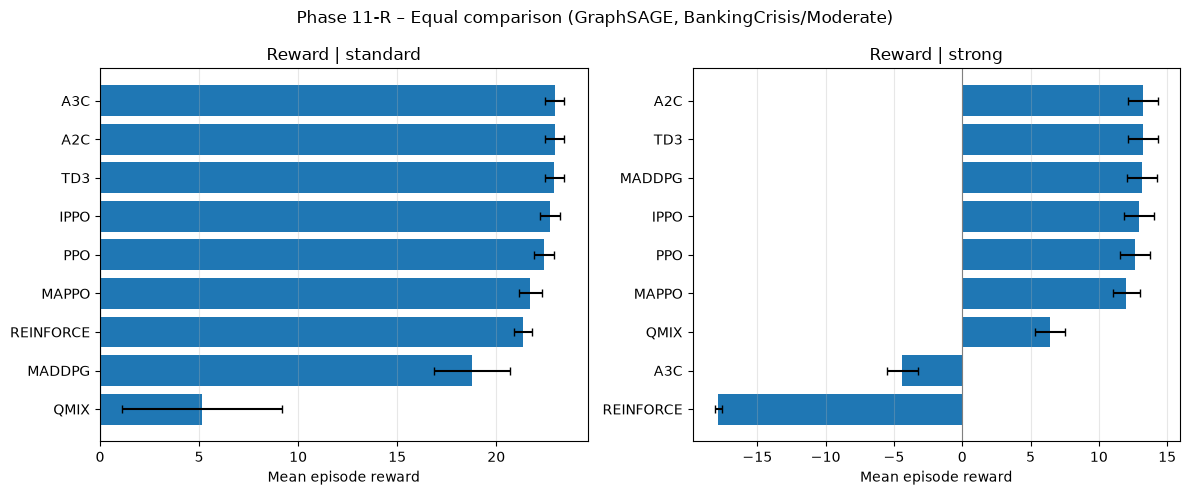

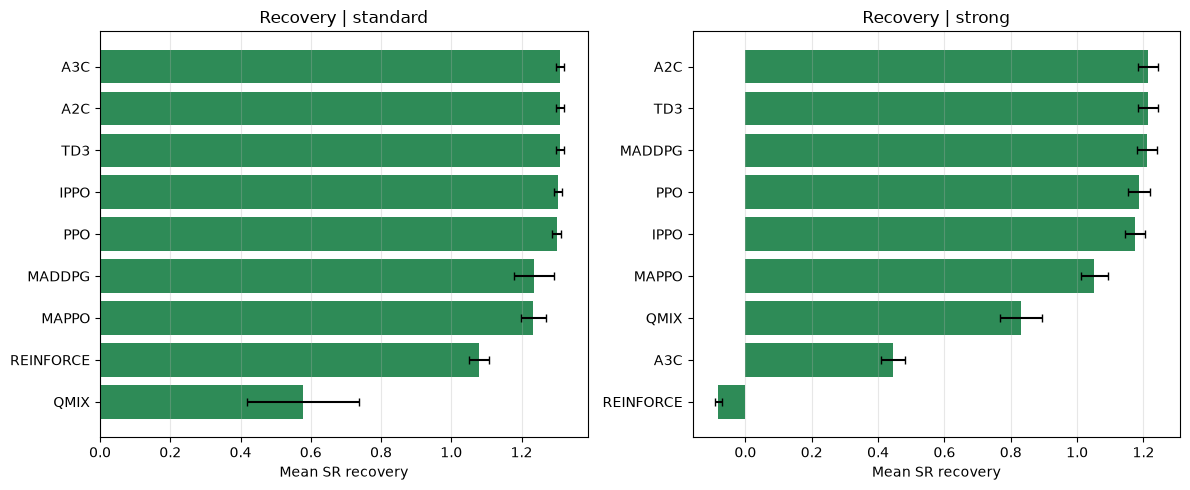


Saved → D:\univercity\omid_project\economics_project\outputs\phase11\tables\phase11r_full_benchmark.csv

Cell 5 completed successfully.
PHASE 11-R EVALUATION COMPLETED.


In [7]:
# Phase 11-R – Cell 5: Full multi-metric benchmark

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase11" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase11" / "figures"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"

print("=" * 60)
print("Phase 11-R – Cell 5: Full multi-metric benchmark")
print("=" * 60)

parts = []
for name in ["phase11r_mappo_ippo.csv", "phase11r_rest_algos.csv"]:
    p = OUT_TAB / name
    if p.exists():
        parts.append(pd.read_csv(p))
        print(f"Loaded {name}: {len(parts[-1])} rows")
    else:
        print(f"Missing: {name}")

bench = pd.concat(parts, ignore_index=True)
bench["embedding"] = "GraphSAGE"
bench["eval_shock"] = "BankingCrisis/Moderate"

# stability proxy: lower std_reward is more stable
bench["stability_score"] = 1.0 / (1.0 + bench["std_reward"].abs())

# composite (informational only; not forced winner)
# z-score within series
rows = []
for series, g in bench.groupby("series"):
    g = g.copy()
    for col in ["mean_reward", "mean_recovery", "stability_score"]:
        mu, sd = g[col].mean(), g[col].std(ddof=0)
        g[f"z_{col}"] = (g[col] - mu) / (sd if sd > 1e-8 else 1.0)
    g["composite"] = g["z_mean_reward"] + g["z_mean_recovery"] + g["z_stability_score"]
    rows.append(g)
bench = pd.concat(rows, ignore_index=True)
bench = bench.sort_values(["series", "mean_reward"], ascending=[True, False])
bench.to_csv(OUT_TAB / "phase11r_full_benchmark.csv", index=False)

for series in ["standard", "strong"]:
    print(f"\n=== {series.upper()} ===")
    cols = ["algorithm", "mean_reward", "std_reward", "median_reward",
            "mean_recovery", "std_recovery", "mean_sr_improve", "backend"]
    print(bench[bench.series == series][cols].to_string(index=False))
    bench[bench.series == series].to_csv(OUT_TAB / f"phase11r_ranking_{series}.csv", index=False)

# plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, series in zip(axes, ["standard", "strong"]):
    sub = bench[bench.series == series].sort_values("mean_reward")
    ax.barh(sub["algorithm"], sub["mean_reward"], xerr=sub["std_reward"], capsize=3)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(f"Reward | {series}")
    ax.set_xlabel("Mean episode reward")
    ax.grid(True, axis="x", alpha=0.3)
fig.suptitle("Phase 11-R – Equal comparison (GraphSAGE, BankingCrisis/Moderate)")
plt.tight_layout()
fig.savefig(OUT_FIG / "phase11r_reward_benchmark.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, series in zip(axes, ["standard", "strong"]):
    sub = bench[bench.series == series].sort_values("mean_recovery")
    ax.barh(sub["algorithm"], sub["mean_recovery"], xerr=sub["std_recovery"], capsize=3, color="seagreen")
    ax.set_title(f"Recovery | {series}")
    ax.set_xlabel("Mean SR recovery")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase11r_recovery_benchmark.png", dpi=150)
plt.show()

meta = {
    "embedding": "GraphSAGE",
    "algorithms": sorted(bench["algorithm"].unique().tolist()),
    "series": ["standard", "strong"],
    "metrics": ["mean_reward", "std_reward", "median_reward", "mean_recovery", "std_recovery", "mean_sr_improve"],
    "timesteps": 50000,
    "note": "Equal protocol; no preselected winner; model for next phase chosen externally",
    "benchmark_csv": str(OUT_TAB / "phase11r_full_benchmark.csv"),
}
(OUT_DATA / "phase11r_benchmark_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"\nSaved → {OUT_TAB / 'phase11r_full_benchmark.csv'}")
print("\nCell 5 completed successfully.")
print("PHASE 11-R EVALUATION COMPLETED.")

In [1]:
# Phase 11-R Fix | Cell A: Ray health check
import sys
print("Python:", sys.version)

import ray
print("ray:", ray.__version__)

# Must NOT import ray.tune.registry first if broken; test core RLlib
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.env.wrappers.pettingzoo_env import ParallelPettingZooEnv
print("PPOConfig OK")
print("ParallelPettingZooEnv OK")

# Optional tune registry
try:
    from ray.tune.registry import register_env
    print("register_env OK")
except Exception as e:
    print("register_env FAIL:", type(e).__name__, e)
    print("→ از environment(env=callable) بدون register استفاده می‌کنیم")

if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, include_dashboard=False, logging_level="ERROR")
print("ray.init OK | resources:", ray.available_resources())
print("Cell A completed successfully.")

Python: 3.12.9 (tags/v3.12.9:fdb8142, Feb  4 2025, 15:27:58) [MSC v.1942 64 bit (AMD64)]


c:\Users\maka\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-10-02 11:03:40,373	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


ray: 2.58.0


2026-10-02 11:03:51,231	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


PPOConfig OK
ParallelPettingZooEnv OK
register_env OK
ray.init OK | resources: {'memory': 692139213.0, 'node:127.0.0.1': 1.0, 'object_store_memory': 296631091.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
Cell A completed successfully.


In [2]:
# Phase 11-R Fix | Cell B: Load env + shared helpers

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import ray
from ray.rllib.env.wrappers.pettingzoo_env import ParallelPettingZooEnv

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB  = PROJECT / "outputs" / "phase11" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase11" / "figures"
for d in [OUT_MODEL, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

for p in [str(P8), str(P10), str(OUT_DATA)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from economics_ma_pettingzoo import EconomicsMAParallelEnv, AGENTS

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

TOTAL_TIMESTEPS = 50000
EVAL_EPISODES = 20
TRAIN_SHOCK = ("BankingCrisis", "Moderate")
SERIES_LIST = ["standard", "strong"]
SEED = 0

def make_raw_env(series, seed=SEED):
    return EconomicsMAParallelEnv(
        base_features, emb, sr, panel, nodes,
        level="moderate",
        shock_type=TRAIN_SHOCK[0], severity=TRAIN_SHOCK[1],
        shock_series=series, seed=seed,
    )

def make_rllib_env(series, seed=SEED):
    return ParallelPettingZooEnv(make_raw_env(series, seed=seed))

def evaluate_algo(algo, series, independent=False, n_ep=EVAL_EPISODES, seed=10_000):
    rewards, recoveries, sr_imps = [], [], []
    for ep in range(n_ep):
        env = make_raw_env(series, seed=seed + ep)
        obs_dict, infos = env.reset(seed=seed + ep)
        sr0 = float(np.mean(env._base.current_sr))
        ep_r, info_last = 0.0, {}
        while env.agents:
            actions = {}
            for a, o in obs_dict.items():
                pid = a if independent else "shared_policy"
                try:
                    act = algo.compute_single_action(o, policy_id=pid)
                except Exception:
                    act = algo.compute_single_action(o)
                if isinstance(act, tuple):
                    act = act[0]
                actions[a] = np.asarray(act, dtype=np.float32)
            obs_dict, rews, terms, truncs, infos = env.step(actions)
            ep_r += float(np.mean(list(rews.values())))
            info_last = list(infos.values())[0] if infos else {}
            if any(terms.values()) or any(truncs.values()):
                break
        rewards.append(ep_r)
        recoveries.append(float(np.mean(env._base.current_sr)) - sr0)
        sr_imps.append(info_last.get("sr_improve", np.nan))
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "median_reward": float(np.median(rewards)),
        "mean_recovery": float(np.mean(recoveries)),
        "std_recovery": float(np.std(recoveries)),
        "mean_sr_improve": float(np.nanmean(sr_imps)),
    }

print("Agents:", AGENTS)
print("Series:", SERIES_LIST)
print("Cell B completed successfully.")

Agents: ['Government', 'CentralBank', 'BankingSector']
Series: ['standard', 'strong']
Cell B completed successfully.


In [4]:
# Phase 11-R Fix | Cell C (fixed): Real RLlib MAPPO + IPPO with register_env

from ray.tune.registry import register_env
from ray.rllib.algorithms.ppo import PPOConfig

print("=" * 60)
print("Cell C (fixed): Real MAPPO + IPPO (RLlib)")
print("=" * 60)

if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, include_dashboard=False, logging_level="ERROR")

def build_ma_ppo(series, independent=False):
    env_name = f"econ_ma_{series}_{'ippo' if independent else 'mappo'}"

    def env_creator(config):
        return make_rllib_env(series, SEED)

    register_env(env_name, env_creator)

    probe = make_rllib_env(series, 0)
    obs_space, act_space = probe.observation_space, probe.action_space
    if hasattr(obs_space, "spaces"):
        sample_obs = list(obs_space.spaces.values())[0]
        sample_act = list(act_space.spaces.values())[0]
        agent_ids = list(obs_space.spaces.keys())
    else:
        sample_obs, sample_act, agent_ids = obs_space, act_space, list(AGENTS)
    probe.close()

    if independent:
        policies = {a: (None, sample_obs, sample_act, {}) for a in agent_ids}
        mapping = lambda agent_id, *args, **kwargs: agent_id
        train_pols = list(agent_ids)
        tag = "IPPO"
    else:
        policies = {"shared_policy": (None, sample_obs, sample_act, {})}
        mapping = lambda agent_id, *args, **kwargs: "shared_policy"
        train_pols = ["shared_policy"]
        tag = "MAPPO"

    cfg = (
        PPOConfig()
        .environment(env=env_name, disable_env_checking=True)
        .framework("torch")
        .env_runners(num_env_runners=0, num_envs_per_env_runner=1, rollout_fragment_length=40)
        .training(
            lr=3e-4, gamma=0.99,
            train_batch_size=2048, minibatch_size=256, num_epochs=10,
            model={"fcnet_hiddens": [128, 128]},
        )
        .multi_agent(policies=policies, policy_mapping_fn=mapping, policies_to_train=train_pols)
        .debugging(log_level="ERROR")
        .api_stack(enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False)
    )
    algo = cfg.build()
    return algo, tag

def train_until(algo, total_steps):
    steps, it = 0, 0
    while steps < total_steps:
        result = algo.train()
        ts = (
            result.get("num_env_steps_sampled_lifetime")
            or result.get("env_runners", {}).get("num_env_steps_sampled_lifetime")
            or result.get("timesteps_total")
            or 0
        )
        steps = int(ts) if ts else steps + 2048
        it += 1
        if it % 5 == 0:
            rew = (
                result.get("env_runners", {}).get("episode_return_mean")
                or result.get("episode_reward_mean")
            )
            print(f"  iter={it:03d} | steps≈{steps} | return={rew}")
        if it > 500:
            break
    return steps

rows = []
for series in SERIES_LIST:
    for independent in [False, True]:
        algo, tag = build_ma_ppo(series, independent=independent)
        print(f"\n===== {tag} | {series} | target_steps={TOTAL_TIMESTEPS} =====")
        trained_steps = train_until(algo, TOTAL_TIMESTEPS)
        ckpt = algo.save(str(OUT_MODEL / f"{tag}_{series}_rllib"))
        print("Saved:", ckpt)
        st = evaluate_algo(algo, series, independent=independent)
        st.update({
            "algorithm": tag, "series": series,
            "timesteps": trained_steps, "backend": "rllib_real",
        })
        rows.append(st)
        print(f"Eval | R={st['mean_reward']:.3f}±{st['std_reward']:.3f} | recovery={st['mean_recovery']:.3f}")
        algo.stop()

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase11r_mappo_ippo_REAL.csv", index=False)
print("\n", df.to_string(index=False))
print("Cell C completed successfully.")

Cell C (fixed): Real MAPPO + IPPO (RLlib)

===== MAPPO | standard | target_steps=50000 =====
  iter=005 | steps≈10400 | return=-22.36081776080235
  iter=010 | steps≈20800 | return=-2.21108370797532
  iter=015 | steps≈31200 | return=6.078111027551509
  iter=020 | steps≈41600 | return=11.904451218927942
  iter=025 | steps≈52000 | return=14.171564555020513
Saved: TrainingResult(checkpoint=Checkpoint(filesystem=local, path=D:\univercity\omid_project\economics_project\outputs\phase11\models\MAPPO_standard_rllib), metrics={'custom_metrics': {}, 'episode_media': {}, 'info': {'learner': {'shared_policy': {'learner_stats': {'allreduce_latency': 0.0, 'grad_gnorm': 17.681482079029085, 'cur_kl_coeff': 0.15, 'cur_lr': 0.0003, 'total_loss': 1.519047167301178, 'policy_loss': -0.0017670397534966468, 'vf_loss': 1.5197310113906861, 'vf_explained_var': 0.684923914194107, 'kl': 0.00722130690165799, 'entropy': 2.002656066417694, 'entropy_coeff': 0.0}, 'model': {}, 'custom_metrics': {}, 'num_agent_steps_tra

In [7]:
# Phase 11-R Fix | Cell D (fixed): True MADDPG (centralized critic)

import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random
import numpy as np
import pandas as pd

print("=" * 60)
print("Cell D (fixed): MADDPG centralized-critic")
print("=" * 60)

device = torch.device("cpu")
ACT_DIM = 2
N_AGENTS = 3
OBS_DIM = 69
JOINT_ACT = N_AGENTS * ACT_DIM
BUFFER = 50000
BATCH = 256
GAMMA = 0.99
TAU = 0.01
LR = 3e-4
NOISE = 0.1

class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(OBS_DIM, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, ACT_DIM), nn.Tanh(),
        )
    def forward(self, obs):
        return self.net(obs)

class CentralCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(OBS_DIM + JOINT_ACT, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, obs, joint_actions):
        return self.net(torch.cat([obs, joint_actions], dim=-1)).squeeze(-1)

class MADDPGAgent:
    def __init__(self):
        self.actors = [Actor().to(device) for _ in range(N_AGENTS)]
        self.actors_t = [Actor().to(device) for _ in range(N_AGENTS)]
        self.critic = CentralCritic().to(device)
        self.critic_t = CentralCritic().to(device)
        for i in range(N_AGENTS):
            self.actors_t[i].load_state_dict(self.actors[i].state_dict())
        self.critic_t.load_state_dict(self.critic.state_dict())
        self.opt_a = [torch.optim.Adam(a.parameters(), lr=LR) for a in self.actors]
        self.opt_c = torch.optim.Adam(self.critic.parameters(), lr=LR)
        self.buf = deque(maxlen=BUFFER)

    @torch.no_grad()
    def act(self, obs, noise=True):
        o = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        acts = []
        for ac in self.actors:
            a = ac(o).squeeze(0).cpu().numpy()
            if noise:
                a = a + NOISE * np.random.randn(ACT_DIM)
            acts.append(np.clip(a, -1, 1).astype(np.float32))
        return acts  # list of 3 arrays shape (2,)

    def push(self, obs, acts, rew, nobs, done):
        self.buf.append((obs, np.concatenate(acts), rew, nobs, float(done)))

    def update(self):
        if len(self.buf) < BATCH:
            return
        batch = random.sample(self.buf, BATCH)
        o = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32, device=device)
        a = torch.tensor(np.array([b[1] for b in batch]), dtype=torch.float32, device=device)
        r = torch.tensor([b[2] for b in batch], dtype=torch.float32, device=device)
        no = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32, device=device)
        d = torch.tensor([b[4] for b in batch], dtype=torch.float32, device=device)

        with torch.no_grad():
            na = torch.cat([at(no) for at in self.actors_t], dim=-1)
            tq = r + GAMMA * (1 - d) * self.critic_t(no, na)
        q = self.critic(o, a)
        loss_c = F.mse_loss(q, tq)
        self.opt_c.zero_grad(); loss_c.backward(); self.opt_c.step()

        # actor losses (each agent)
        for i in range(N_AGENTS):
            pred_parts = []
            for j, ac in enumerate(self.actors):
                pred_parts.append(ac(o) if j == i else ac(o).detach())
            pred_joint = torch.cat(pred_parts, dim=-1)
            loss_a = -self.critic(o, pred_joint).mean()
            self.opt_a[i].zero_grad(); loss_a.backward(); self.opt_a[i].step()

        # soft update
        with torch.no_grad():
            for ac, at in zip(self.actors, self.actors_t):
                for p, pt in zip(ac.parameters(), at.parameters()):
                    pt.data.mul_(1 - TAU).add_(TAU * p.data)
            for p, pt in zip(self.critic.parameters(), self.critic_t.parameters()):
                pt.data.mul_(1 - TAU).add_(TAU * p.data)

def train_maddpg(series):
    agent = MADDPGAgent()
    steps = 0
    ep = 0
    while steps < TOTAL_TIMESTEPS:
        env = make_raw_env(series, seed=SEED + ep)
        obs_dict, _ = env.reset(seed=SEED + ep)
        ep_r = 0.0
        while env.agents:
            obs = next(iter(obs_dict.values()))
            acts_list = agent.act(obs, noise=True)
            ad = {
                "Government": acts_list[0],
                "CentralBank": acts_list[1],
                "BankingSector": acts_list[2],
            }
            nobs_dict, rews, terms, truncs, infos = env.step(ad)
            done = any(terms.values()) or any(truncs.values())
            nobs = next(iter(nobs_dict.values())) if nobs_dict else obs
            r = float(np.mean(list(rews.values())))
            agent.push(obs, acts_list, r, nobs, done)
            agent.update()
            ep_r += r
            steps += 1
            obs_dict = nobs_dict
            if done:
                break
        ep += 1
        if ep % 50 == 0:
            print(f"  ep={ep} | steps={steps} | last_ep_R={ep_r:.3f}")
    # save
    for i, name in enumerate(AGENTS):
        torch.save(agent.actors[i].state_dict(), OUT_MODEL / f"MADDPG_{name}_{series}_real.pt")
    torch.save(agent.critic.state_dict(), OUT_MODEL / f"MADDPG_critic_{series}_real.pt")
    return agent

def eval_maddpg(agent, series):
    rewards, recoveries, sr_imps = [], [], []
    for e in range(EVAL_EPISODES):
        env = make_raw_env(series, seed=10_000 + e)
        obs_dict, infos = env.reset(seed=10_000 + e)
        sr0 = float(np.mean(env._base.current_sr))
        ep_r, info_last = 0.0, {}
        while env.agents:
            obs = next(iter(obs_dict.values()))
            acts_list = agent.act(obs, noise=False)
            ad = {
                "Government": acts_list[0],
                "CentralBank": acts_list[1],
                "BankingSector": acts_list[2],
            }
            obs_dict, rews, terms, truncs, infos = env.step(ad)
            ep_r += float(np.mean(list(rews.values())))
            info_last = list(infos.values())[0] if infos else {}
            if any(terms.values()) or any(truncs.values()):
                break
        rewards.append(ep_r)
        recoveries.append(float(np.mean(env._base.current_sr)) - sr0)
        sr_imps.append(info_last.get("sr_improve", np.nan))
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "median_reward": float(np.median(rewards)),
        "mean_recovery": float(np.mean(recoveries)),
        "std_recovery": float(np.std(recoveries)),
        "mean_sr_improve": float(np.nanmean(sr_imps)),
    }

rows = []
for series in SERIES_LIST:
    print(f"\n===== MADDPG | {series} | steps={TOTAL_TIMESTEPS} =====")
    agent = train_maddpg(series)
    st = eval_maddpg(agent, series)
    st.update({
        "algorithm": "MADDPG", "series": series,
        "timesteps": TOTAL_TIMESTEPS, "backend": "maddpg_centralized_critic",
    })
    rows.append(st)
    print(f"Eval | R={st['mean_reward']:.3f}±{st['std_reward']:.3f} | recovery={st['mean_recovery']:.3f}")

pd.DataFrame(rows).to_csv(OUT_TAB / "phase11r_maddpg_REAL.csv", index=False)
print("\nCell D completed successfully.")

Cell D (fixed): MADDPG centralized-critic

===== MADDPG | standard | steps=50000 =====
  ep=50 | steps=2000 | last_ep_R=18.355
  ep=100 | steps=4000 | last_ep_R=19.911
  ep=150 | steps=6000 | last_ep_R=15.468
  ep=200 | steps=8000 | last_ep_R=15.988
  ep=250 | steps=10000 | last_ep_R=18.102
  ep=300 | steps=12000 | last_ep_R=17.977
  ep=350 | steps=14000 | last_ep_R=17.694
  ep=400 | steps=16000 | last_ep_R=16.900
  ep=450 | steps=18000 | last_ep_R=17.474
  ep=500 | steps=20000 | last_ep_R=17.641
  ep=550 | steps=22000 | last_ep_R=17.163
  ep=600 | steps=24000 | last_ep_R=17.934
  ep=650 | steps=26000 | last_ep_R=16.708
  ep=700 | steps=28000 | last_ep_R=17.229
  ep=750 | steps=30000 | last_ep_R=18.262
  ep=800 | steps=32000 | last_ep_R=17.316
  ep=850 | steps=34000 | last_ep_R=16.188
  ep=900 | steps=36000 | last_ep_R=15.707
  ep=950 | steps=38000 | last_ep_R=17.596
  ep=1000 | steps=40000 | last_ep_R=16.831
  ep=1050 | steps=42000 | last_ep_R=17.927
  ep=1100 | steps=44000 | last_ep_

In [8]:
# Phase 11-R Fix | Cell E (fixed): QMIX with mixing network

import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random
import numpy as np
import pandas as pd

print("=" * 60)
print("Cell E (fixed): QMIX mixing-network")
print("=" * 60)

device = torch.device("cpu")
OBS_DIM = 69
N_AGENTS = 3
N_BINS = 3
N_ACT = N_BINS * N_BINS  # 9 discrete actions per agent
HIDDEN = 64
BATCH = 256
GAMMA = 0.99
LR = 1e-3
BUFFER = 50000
EPISODES = TOTAL_TIMESTEPS // 40

def idx_to_cont(idx):
    d0, d1 = int(idx) % N_BINS, int(idx) // N_BINS
    return np.array([-1 + 2 * d0 / (N_BINS - 1), -1 + 2 * d1 / (N_BINS - 1)], dtype=np.float32)

class AgentQ(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(OBS_DIM, 128), nn.ReLU(),
            nn.Linear(128, HIDDEN), nn.ReLU(),
            nn.Linear(HIDDEN, N_ACT),
        )
    def forward(self, obs):
        return self.net(obs)

class QMixer(nn.Module):
    """Standard QMIX monotonic mixer (hypernetwork)."""
    def __init__(self):
        super().__init__()
        self.embed = HIDDEN
        self.hyper_w1 = nn.Linear(OBS_DIM, N_AGENTS * self.embed)
        self.hyper_b1 = nn.Linear(OBS_DIM, self.embed)
        self.hyper_w2 = nn.Linear(OBS_DIM, self.embed)
        self.hyper_b2 = nn.Sequential(nn.Linear(OBS_DIM, self.embed), nn.ReLU(), nn.Linear(self.embed, 1))

    def forward(self, agent_qs, state):
        # agent_qs: [B, N_AGENTS]  state: [B, OBS_DIM]
        bs = agent_qs.size(0)
        w1 = torch.abs(self.hyper_w1(state)).view(bs, N_AGENTS, self.embed)
        b1 = self.hyper_b1(state).view(bs, 1, self.embed)
        hidden = F.elu(torch.bmm(agent_qs.unsqueeze(1), w1) + b1)
        w2 = torch.abs(self.hyper_w2(state)).view(bs, self.embed, 1)
        b2 = self.hyper_b2(state).view(bs, 1, 1)
        q_tot = torch.bmm(hidden, w2) + b2
        return q_tot.squeeze(-1).squeeze(-1)

class QMIXLearner:
    def __init__(self):
        self.qs = [AgentQ().to(device) for _ in range(N_AGENTS)]
        self.qs_t = [AgentQ().to(device) for _ in range(N_AGENTS)]
        self.mixer = QMixer().to(device)
        self.mixer_t = QMixer().to(device)
        for i in range(N_AGENTS):
            self.qs_t[i].load_state_dict(self.qs[i].state_dict())
        self.mixer_t.load_state_dict(self.mixer.state_dict())
        params = list(self.mixer.parameters())
        for q in self.qs:
            params += list(q.parameters())
        self.opt = torch.optim.Adam(params, lr=LR)
        self.buf = deque(maxlen=BUFFER)

    @torch.no_grad()
    def act(self, obs, eps):
        o = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        idxs = []
        for q in self.qs:
            if random.random() < eps:
                idxs.append(random.randrange(N_ACT))
            else:
                idxs.append(int(q(o).argmax(dim=-1).item()))
        return idxs

    def push(self, obs, idxs, rew, nobs, done):
        self.buf.append((obs, idxs, rew, nobs, float(done)))

    def update(self):
        if len(self.buf) < BATCH:
            return
        batch = random.sample(self.buf, BATCH)
        o = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32, device=device)
        no = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32, device=device)
        r = torch.tensor([b[2] for b in batch], dtype=torch.float32, device=device)
        d = torch.tensor([b[4] for b in batch], dtype=torch.float32, device=device)
        idxs = [b[1] for b in batch]

        # chosen Q_i
        q_chosen = []
        for i, q in enumerate(self.qs):
            a_i = torch.tensor([ix[i] for ix in idxs], dtype=torch.int64, device=device)
            q_chosen.append(q(o).gather(1, a_i.view(-1, 1)).squeeze(1))
        q_chosen = torch.stack(q_chosen, dim=1)  # [B, N]
        q_tot = self.mixer(q_chosen, o)

        with torch.no_grad():
            q_next = []
            for i, (q, qt) in enumerate(zip(self.qs, self.qs_t)):
                # double-style: argmax online, value target
                a_star = q(no).argmax(dim=1)
                q_next.append(qt(no).gather(1, a_star.view(-1, 1)).squeeze(1))
            q_next = torch.stack(q_next, dim=1)
            q_tot_t = self.mixer_t(q_next, no)
            target = r + GAMMA * (1 - d) * q_tot_t

        loss = F.mse_loss(q_tot, target)
        self.opt.zero_grad(); loss.backward(); self.opt.step()

    def sync_target(self, tau=1.0):
        for q, qt in zip(self.qs, self.qs_t):
            for p, pt in zip(q.parameters(), qt.parameters()):
                pt.data.mul_(1 - tau).add_(tau * p.data)
        for p, pt in zip(self.mixer.parameters(), self.mixer_t.parameters()):
            pt.data.mul_(1 - tau).add_(tau * p.data)

def train_qmix(series):
    learner = QMIXLearner()
    steps = 0
    eps = 1.0
    ep = 0
    while steps < TOTAL_TIMESTEPS:
        env = make_raw_env(series, seed=SEED + ep)
        obs_dict, _ = env.reset(seed=SEED + ep)
        while env.agents:
            obs = next(iter(obs_dict.values()))
            idxs = learner.act(obs, eps)
            ad = {
                "Government": idx_to_cont(idxs[0]),
                "CentralBank": idx_to_cont(idxs[1]),
                "BankingSector": idx_to_cont(idxs[2]),
            }
            nobs_dict, rews, terms, truncs, infos = env.step(ad)
            done = any(terms.values()) or any(truncs.values())
            nobs = next(iter(nobs_dict.values())) if nobs_dict else obs
            r = float(np.mean(list(rews.values())))
            learner.push(obs, idxs, r, nobs, done)
            learner.update()
            steps += 1
            obs_dict = nobs_dict
            if done:
                break
        eps = max(0.05, eps * 0.995)
        if ep % 25 == 0:
            learner.sync_target(tau=1.0)
            print(f"  ep={ep} | steps={steps} | eps={eps:.3f}")
        ep += 1
    for i, name in enumerate(AGENTS):
        torch.save(learner.qs[i].state_dict(), OUT_MODEL / f"QMIX_{name}_{series}_real.pt")
    torch.save(learner.mixer.state_dict(), OUT_MODEL / f"QMIX_mixer_{series}_real.pt")
    return learner

def eval_qmix(learner, series):
    rewards, recoveries, sr_imps = [], [], []
    for e in range(EVAL_EPISODES):
        env = make_raw_env(series, seed=10_000 + e)
        obs_dict, infos = env.reset(seed=10_000 + e)
        sr0 = float(np.mean(env._base.current_sr))
        ep_r, info_last = 0.0, {}
        while env.agents:
            obs = next(iter(obs_dict.values()))
            idxs = learner.act(obs, eps=0.0)
            ad = {
                "Government": idx_to_cont(idxs[0]),
                "CentralBank": idx_to_cont(idxs[1]),
                "BankingSector": idx_to_cont(idxs[2]),
            }
            obs_dict, rews, terms, truncs, infos = env.step(ad)
            ep_r += float(np.mean(list(rews.values())))
            info_last = list(infos.values())[0] if infos else {}
            if any(terms.values()) or any(truncs.values()):
                break
        rewards.append(ep_r)
        recoveries.append(float(np.mean(env._base.current_sr)) - sr0)
        sr_imps.append(info_last.get("sr_improve", np.nan))
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "median_reward": float(np.median(rewards)),
        "mean_recovery": float(np.mean(recoveries)),
        "std_recovery": float(np.std(recoveries)),
        "mean_sr_improve": float(np.nanmean(sr_imps)),
    }

rows = []
for series in SERIES_LIST:
    print(f"\n===== QMIX | {series} | steps={TOTAL_TIMESTEPS} =====")
    learner = train_qmix(series)
    st = eval_qmix(learner, series)
    st.update({
        "algorithm": "QMIX", "series": series,
        "timesteps": TOTAL_TIMESTEPS, "backend": "qmix_mixing_network",
    })
    rows.append(st)
    print(f"Eval | R={st['mean_reward']:.3f}±{st['std_reward']:.3f} | recovery={st['mean_recovery']:.3f}")

pd.DataFrame(rows).to_csv(OUT_TAB / "phase11r_qmix_REAL.csv", index=False)
print("\nCell E completed successfully.")

Cell E (fixed): QMIX mixing-network

===== QMIX | standard | steps=50000 =====
  ep=0 | steps=40 | eps=0.995
  ep=25 | steps=1040 | eps=0.878
  ep=50 | steps=2040 | eps=0.774
  ep=75 | steps=3040 | eps=0.683
  ep=100 | steps=4040 | eps=0.603
  ep=125 | steps=5040 | eps=0.532
  ep=150 | steps=6040 | eps=0.469
  ep=175 | steps=7040 | eps=0.414
  ep=200 | steps=8040 | eps=0.365
  ep=225 | steps=9040 | eps=0.322
  ep=250 | steps=10040 | eps=0.284
  ep=275 | steps=11040 | eps=0.251
  ep=300 | steps=12040 | eps=0.221
  ep=325 | steps=13040 | eps=0.195
  ep=350 | steps=14040 | eps=0.172
  ep=375 | steps=15040 | eps=0.152
  ep=400 | steps=16040 | eps=0.134
  ep=425 | steps=17040 | eps=0.118
  ep=450 | steps=18040 | eps=0.104
  ep=475 | steps=19040 | eps=0.092
  ep=500 | steps=20040 | eps=0.081
  ep=525 | steps=21040 | eps=0.072
  ep=550 | steps=22040 | eps=0.063
  ep=575 | steps=23040 | eps=0.056
  ep=600 | steps=24040 | eps=0.050
  ep=625 | steps=25040 | eps=0.050
  ep=650 | steps=26040 | eps

Cell F (fixed): Final merge REAL multi-agent
Loaded REAL: phase11r_mappo_ippo_REAL.csv | rows=4 | backend=['rllib_real']
Loaded REAL: phase11r_maddpg_REAL.csv | rows=2 | backend=['maddpg_centralized_critic']
Loaded REAL: phase11r_qmix_REAL.csv | rows=2 | backend=['qmix_mixing_network']
Single-policy rows kept: 10

=== STANDARD ===
algorithm  mean_reward  std_reward  median_reward  mean_recovery  mean_sr_improve                   backend
      A2C    22.947198    0.486672      22.929833       1.309579         1.158371                       sb3
      A3C    22.947198    0.486672      22.929833       1.309579         1.158371                     torch
      TD3    22.926725    0.479299      22.929461       1.309528         1.158319                       sb3
      PPO    22.404574    0.485370      22.471721       1.299548         1.148339                       sb3
REINFORCE    21.348723    0.469795      21.280576       1.079488         0.928279                     torch
   MADDPG    17.870

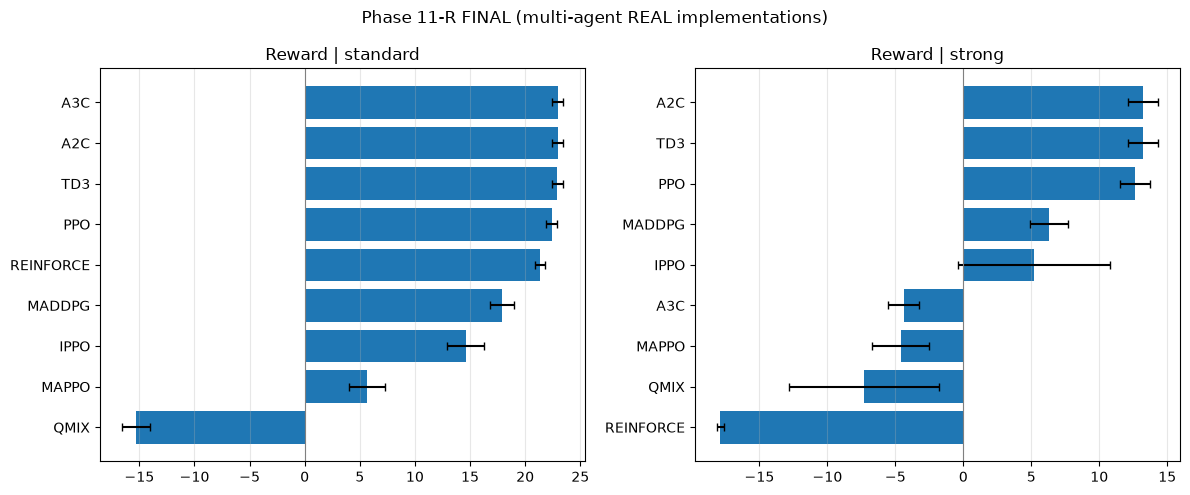


Saved → D:\univercity\omid_project\economics_project\outputs\phase11\tables\phase11r_full_benchmark_REAL.csv
PHASE 11 MULTI-AGENT LIMITATIONS CLOSED.
Cell F completed successfully.


In [10]:
# Phase 11-R Fix | Cell F (fixed): Merge all REAL multi-agent results

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json
import numpy as np

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase11" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase11" / "figures"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"

print("=" * 60)
print("Cell F (fixed): Final merge REAL multi-agent")
print("=" * 60)

ALLOWED_BACKENDS = {
    "rllib_real",
    "maddpg_centralized_critic",
    "qmix_mixing_network",
}

ma_files = [
    OUT_TAB / "phase11r_mappo_ippo_REAL.csv",
    OUT_TAB / "phase11r_maddpg_REAL.csv",
    OUT_TAB / "phase11r_qmix_REAL.csv",
]
ma = []
for f in ma_files:
    if not f.exists():
        raise FileNotFoundError(f"Missing REAL result: {f}")
    df = pd.read_csv(f)
    bad = set(df["backend"].unique()) - ALLOWED_BACKENDS
    if bad:
        raise RuntimeError(f"Invalid backend in {f.name}: {bad}")
    ma.append(df)
    print(f"Loaded REAL: {f.name} | rows={len(df)} | backend={list(df['backend'].unique())}")

# single-policy valid algorithms from earlier equal run
rest_path = OUT_TAB / "phase11r_rest_algos.csv"
if rest_path.exists():
    rest = pd.read_csv(rest_path)
    single = rest[rest["algorithm"].isin(["PPO", "A2C", "A3C", "REINFORCE", "TD3"])].copy()
    print("Single-policy rows kept:", len(single))
else:
    single = pd.DataFrame()
    print("No single-policy file; MA only")

bench = pd.concat(ma + ([single] if len(single) else []), ignore_index=True)
bench["embedding"] = "GraphSAGE"
bench["eval_shock"] = "BankingCrisis/Moderate"
bench["stability_score"] = 1.0 / (1.0 + bench["std_reward"].abs())
bench = bench.sort_values(["series", "mean_reward"], ascending=[True, False])
bench.to_csv(OUT_TAB / "phase11r_full_benchmark_REAL.csv", index=False)

for series in ["standard", "strong"]:
    print(f"\n=== {series.upper()} ===")
    cols = ["algorithm", "mean_reward", "std_reward", "median_reward",
            "mean_recovery", "mean_sr_improve", "backend"]
    sub = bench[bench.series == series]
    print(sub[cols].to_string(index=False))
    sub.to_csv(OUT_TAB / f"phase11r_ranking_{series}_REAL.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, series in zip(axes, ["standard", "strong"]):
    sub = bench[bench.series == series].sort_values("mean_reward")
    ax.barh(sub["algorithm"], sub["mean_reward"], xerr=sub["std_reward"], capsize=3)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(f"Reward | {series}")
    ax.grid(True, axis="x", alpha=0.3)
fig.suptitle("Phase 11-R FINAL (multi-agent REAL implementations)")
plt.tight_layout()
fig.savefig(OUT_FIG / "phase11r_final_real_benchmark.png", dpi=150)
plt.show()

meta = {
    "status": "multi_agent_limitations_closed",
    "MAPPO_IPPO": "rllib_real",
    "MADDPG": "maddpg_centralized_critic",
    "QMIX": "qmix_mixing_network",
    "benchmark": str(OUT_TAB / "phase11r_full_benchmark_REAL.csv"),
}
(OUT_DATA / "phase11r_REAL_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
print(f"\nSaved → {OUT_TAB / 'phase11r_full_benchmark_REAL.csv'}")
print("PHASE 11 MULTI-AGENT LIMITATIONS CLOSED.")
print("Cell F completed successfully.")

In [11]:
# Phase 11-R Extra | Cell G1: Multi-seed eval (30 eps × 3 seeds)

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from stable_baselines3 import PPO, A2C, TD3

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB  = PROJECT / "outputs" / "phase11" / "tables"

for p in [str(P8), str(P10), str(OUT_DATA)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from economics_ma_pettingzoo import EconomicsMAParallelEnv, AGENTS

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

N_EP = 30
SEEDS = [0, 1, 2]
TRAIN_SHOCK = ("BankingCrisis", "Moderate")
SERIES_LIST = ["standard", "strong"]
device = torch.device("cpu")

def make_raw_env(series, seed=0):
    return EconomicsMAParallelEnv(
        base_features, emb, sr, panel, nodes,
        level="moderate",
        shock_type=TRAIN_SHOCK[0], severity=TRAIN_SHOCK[1],
        shock_series=series, seed=seed,
    )

def eval_action_fn(action_fn, series, seed0):
    rewards, recoveries, sr_imps = [], [], []
    for ep in range(N_EP):
        env = make_raw_env(series, seed=seed0 * 1000 + ep)
        obs_dict, infos = env.reset(seed=seed0 * 1000 + ep)
        sr0 = float(np.mean(env._base.current_sr))
        ep_r, info_last = 0.0, {}
        while env.agents:
            obs = next(iter(obs_dict.values()))
            ad = action_fn(obs)
            obs_dict, rews, terms, truncs, infos = env.step(ad)
            ep_r += float(np.mean(list(rews.values())))
            info_last = list(infos.values())[0] if infos else {}
            if any(terms.values()) or any(truncs.values()):
                break
        rewards.append(ep_r)
        recoveries.append(float(np.mean(env._base.current_sr)) - sr0)
        sr_imps.append(info_last.get("sr_improve", np.nan))
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "median_reward": float(np.median(rewards)),
        "mean_recovery": float(np.mean(recoveries)),
        "std_recovery": float(np.std(recoveries)),
        "mean_sr_improve": float(np.nanmean(sr_imps)),
        "n_episodes": N_EP,
    }

# ---- load SB3 single-policy models ----
def sb3_fn(path):
    if "A2C" in path.name:
        m = A2C.load(str(path))
    elif "TD3" in path.name:
        m = TD3.load(str(path))
    else:
        m = PPO.load(str(path))
    def fn(obs, model=m):
        a, _ = model.predict(obs, deterministic=True)
        a = np.asarray(a, dtype=np.float32).reshape(-1)
        if a.size < 6:
            a = np.pad(a, (0, 6 - a.size))
        return {"Government": a[0:2], "CentralBank": a[2:4], "BankingSector": a[4:6]}
    return fn

rows = []
print("=" * 60)
print("G1: Multi-seed robust eval")
print("=" * 60)

for series in SERIES_LIST:
    # SB3 models from phase11
    for algo in ["PPO", "A2C", "TD3"]:
        # try both naming patterns
        candidates = [
            OUT_MODEL / f"{algo}_{series}_r.zip",
            OUT_MODEL / f"{algo}_{series}.zip",
            OUT_MODEL / f"{algo}_{series}_sb3.zip",
        ]
        path = next((p for p in candidates if p.exists()), None)
        if path is None:
            print(f"Skip missing {algo} {series}")
            continue
        fn = sb3_fn(path)
        seed_stats = []
        for s in SEEDS:
            st = eval_action_fn(fn, series, s)
            st.update({"algorithm": algo, "series": series, "seed": s})
            rows.append(st)
            seed_stats.append(st["mean_reward"])
        print(f"{algo:8s} | {series:8s} | mean_over_seeds={np.mean(seed_stats):.3f} ± {np.std(seed_stats):.3f}")

raw = pd.DataFrame(rows)
raw.to_csv(OUT_TAB / "phase11r_eval30x3_raw.csv", index=False)

# summary over seeds
summary = (
    raw.groupby(["algorithm", "series"], as_index=False)
    .agg(
        mean_reward=("mean_reward", "mean"),
        std_across_seeds=("mean_reward", "std"),
        mean_std_reward=("std_reward", "mean"),
        mean_recovery=("mean_recovery", "mean"),
        std_recovery=("std_recovery", "mean"),
        mean_sr_improve=("mean_sr_improve", "mean"),
    )
)
summary.to_csv(OUT_TAB / "phase11r_eval30x3_summary.csv", index=False)
print("\n", summary.sort_values(["series", "mean_reward"], ascending=[True, False]).to_string(index=False))
print("\nCell G1 completed successfully.")

G1: Multi-seed robust eval
PPO      | standard | mean_over_seeds=22.608 ± 0.164
A2C      | standard | mean_over_seeds=23.150 ± 0.162
TD3      | standard | mean_over_seeds=23.135 ± 0.166
PPO      | strong   | mean_over_seeds=12.125 ± 0.107
A2C      | strong   | mean_over_seeds=12.693 ± 0.113
TD3      | strong   | mean_over_seeds=12.693 ± 0.113

 algorithm   series  mean_reward  std_across_seeds  mean_std_reward  mean_recovery  std_recovery  mean_sr_improve
      A2C standard    23.150031          0.198537         0.579426       1.306301      0.011241         1.158002
      TD3 standard    23.135010          0.203364         0.591996       1.306259      0.011273         1.157961
      PPO standard    22.608302          0.201400         0.648142       1.296980      0.013931         1.148681
      A2C   strong    12.693007          0.138444         1.222313       1.201083      0.032160         0.967687
      TD3   strong    12.693006          0.138444         1.222313       1.201083      0

G2: Stability / Recovery ranking

=== STANDARD | stability & recovery ===
algorithm  mean_reward  std_across_seeds  mean_recovery  stability_score  rank_stability  rank_recovery
      A2C    23.150031          0.198537       1.306301         0.562441               1              1
      TD3    23.135010          0.203364       1.306259         0.556992               2              2
      PPO    22.608302          0.201400       1.296980         0.540674               3              3

=== STRONG | stability & recovery ===
algorithm  mean_reward  std_across_seeds  mean_recovery  stability_score  rank_stability  rank_recovery
      TD3    12.693006          0.138444       1.201083         0.423593               1              2
      A2C    12.693007          0.138444       1.201083         0.423593               2              1
      PPO    12.124518          0.131619       1.175238         0.422791               3              3


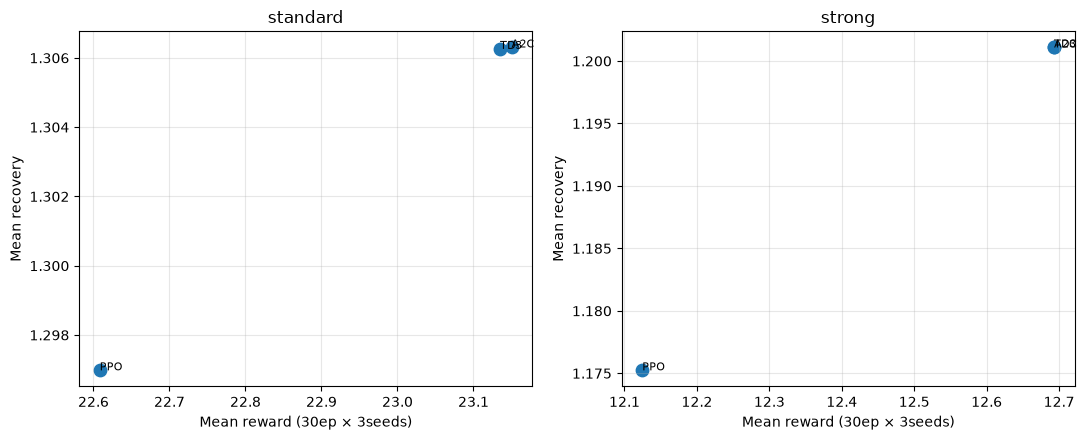


Cell G2 completed successfully.
EXTRA EVAL COMPLETED.


In [12]:
# Phase 11-R Extra | Cell G2: Stability & recovery tables

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase11" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase11" / "figures"

print("=" * 60)
print("G2: Stability / Recovery ranking")
print("=" * 60)

raw = pd.read_csv(OUT_TAB / "phase11r_eval30x3_raw.csv")
summary = pd.read_csv(OUT_TAB / "phase11r_eval30x3_summary.csv")

# stability: lower variance across seeds + lower within-ep std is better
summary["stability_score"] = 1.0 / (1.0 + summary["std_across_seeds"].fillna(0) + summary["mean_std_reward"].fillna(0))
summary["recovery_score"] = summary["mean_recovery"]

for series in ["standard", "strong"]:
    sub = summary[summary.series == series].copy()
    sub = sub.sort_values("stability_score", ascending=False)
    sub["rank_stability"] = range(1, len(sub) + 1)
    sub2 = sub.sort_values("recovery_score", ascending=False)
    sub2["rank_recovery"] = range(1, len(sub2) + 1)
    out = sub.merge(sub2[["algorithm", "rank_recovery"]], on="algorithm")
    out.to_csv(OUT_TAB / f"phase11r_stability_recovery_{series}.csv", index=False)
    print(f"\n=== {series.upper()} | stability & recovery ===")
    print(out[["algorithm", "mean_reward", "std_across_seeds", "mean_recovery",
               "stability_score", "rank_stability", "rank_recovery"]].to_string(index=False))

# plot recovery vs reward
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, series in zip(axes, ["standard", "strong"]):
    sub = summary[summary.series == series]
    ax.scatter(sub["mean_reward"], sub["mean_recovery"], s=80)
    for _, r in sub.iterrows():
        ax.annotate(r["algorithm"], (r["mean_reward"], r["mean_recovery"]), fontsize=8)
    ax.set_xlabel("Mean reward (30ep × 3seeds)")
    ax.set_ylabel("Mean recovery")
    ax.set_title(series)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase11r_reward_vs_recovery.png", dpi=150)
plt.show()

print("\nCell G2 completed successfully.")
print("EXTRA EVAL COMPLETED.")